In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

In [ ]:
df = pd.read_csv("honeyproduction.csv")
print(df.head())
print("Columns In DataSet:", df.columns.tolist())

  state    numcol  yieldpercol   totalprod      stocks  priceperlb  \
0    AL   16000.0           71   1136000.0    159000.0        0.72   
1    AZ   55000.0           60   3300000.0   1485000.0        0.64   
2    AR   53000.0           65   3445000.0   1688000.0        0.59   
3    CA  450000.0           83  37350000.0  12326000.0        0.62   
4    CO   27000.0           72   1944000.0   1594000.0        0.70   

    prodvalue  year  
0    818000.0  1998  
1   2112000.0  1998  
2   2033000.0  1998  
3  23157000.0  1998  
4   1361000.0  1998  
Columns In DataSet: 	 ['state', 'numcol', 'yieldpercol', 'totalprod', 'stocks', 'priceperlb', 'prodvalue', 'year']


In [9]:
# Aggregate total production per year
prod_per_year = df.groupby("year").totalprod.sum().reset_index()
print("Total production of honey per year:", prod_per_year.head(2))


Total production of honey per year:    year    totalprod
0  1998  219519000.0
1  1999  202387000.0


In [10]:
# Normalize years (start at 0 for first year)
X = prod_per_year["year"] - prod_per_year["year"].min()
X = X.values.reshape(-1, 1)
y = prod_per_year["totalprod"]

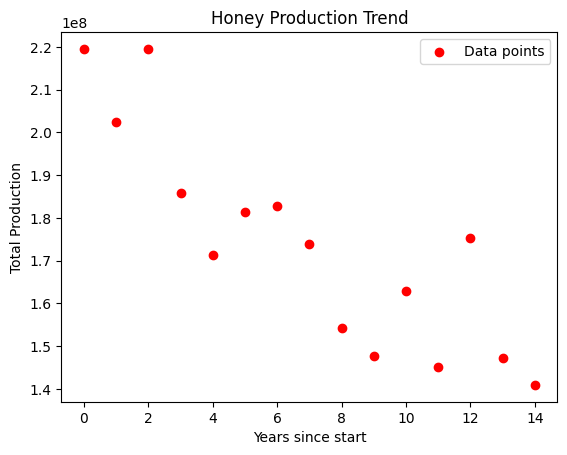

In [11]:
# Scatter plot of actual data
plt.scatter(X, y, color="red", label="Data points")
plt.xlabel("Years since start")
plt.ylabel("Total Production")
plt.title("Honey Production Trend")
plt.legend()
plt.show()

In [12]:
# Fit regression model
regr = LinearRegression()
regr.fit(X, y)
print("Slope of the line:", regr.coef_[0])
print("Intercept (production in first year):", regr.intercept_)

Slope of the line: -4951114.285714286
Intercept (production in first year): 208647666.66666666


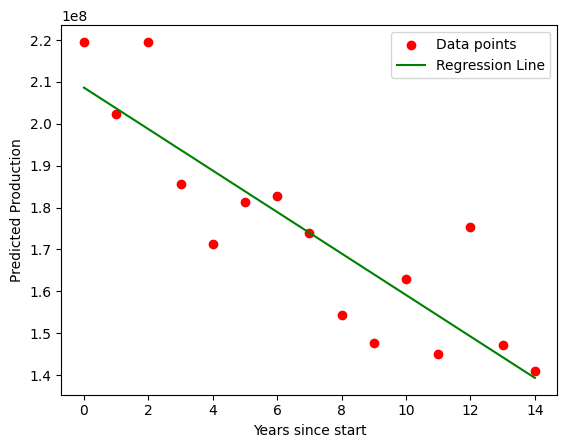

In [14]:
# Predictions on actual years
y_pred = regr.predict(X)
# Plot regression line
plt.scatter(X, y, color="red", label="Data points")
plt.plot(X, y_pred, color="green", label="Regression Line")
plt.xlabel("Years since start")
plt.ylabel("Predicted Production")
plt.legend()
plt.show()

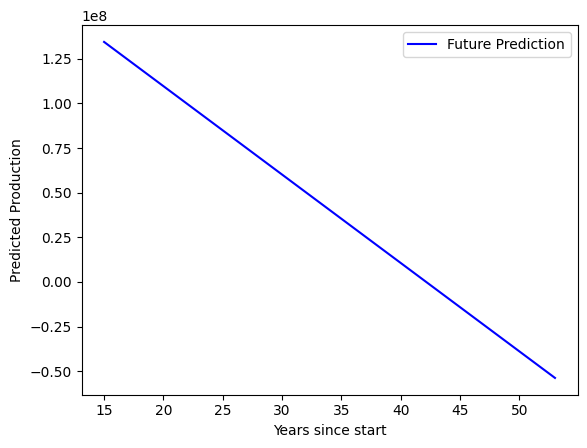

In [15]:
# Future predictions
X_future = np.array(range(X.max() + 1, X.max() + 40)).reshape(-1, 1)
future_predict = regr.predict(X_future)

plt.plot(X_future, future_predict, color="blue", label="Future Prediction")
plt.xlabel("Years since start")
plt.ylabel("Predicted Production")
plt.legend()
plt.show()